# Ridge Regression


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data)
#to write feature names in our dataset :
df.columns = housing.feature_names
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
#Independent (x) and Dependent (y) features:
x = df
y = housing.target #house price


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [7]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

### 👉 Hyperparameter tuning = process of trying different hyperparameter(that is alpha in this case) values to improve model performance.
### 👉 It improves accuracy by choosing better settings for your algorithm.
### for this we use GridSearchCV as it tries all combinations of given hyperparameter values



In [16]:
ridge_reg = Ridge()
parameter={'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}

ridgecv = GridSearchCV(ridge_reg,parameter,scoring='neg_mean_squared_error',cv = 5)

ridgecv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [ ]:
print(ridgecv.best_params_)
print(ridgecv.best_score_) #we can compare this with mse_mean of Linear Reg

{'alpha': 1}
-0.5268263170917393


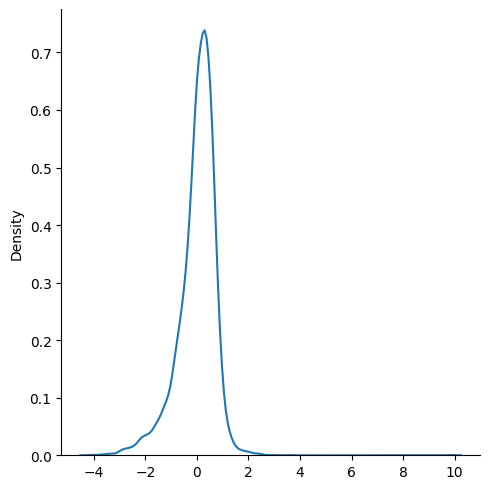

In [21]:
ridge_pred = ridgecv.predict(x_test)
import seaborn as sns
sns.displot(ridge_pred-y_test,kind = 'kde')

In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_test,ridge_pred)
# r2_score take First argument → actual values, Second argument → predicted values
score

0.5958178603951638

# Lasso Regression
- used for automatic feature selection

In [25]:
from sklearn.linear_model import Lasso
lasso = Lasso()
parameter={'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}

lassocv = GridSearchCV(lasso,parameter,scoring='neg_mean_squared_error',cv = 5)

lassocv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [27]:
print(lassocv.best_params_)
print(lassocv.best_score_)

{'alpha': 1}
-0.954264113746258


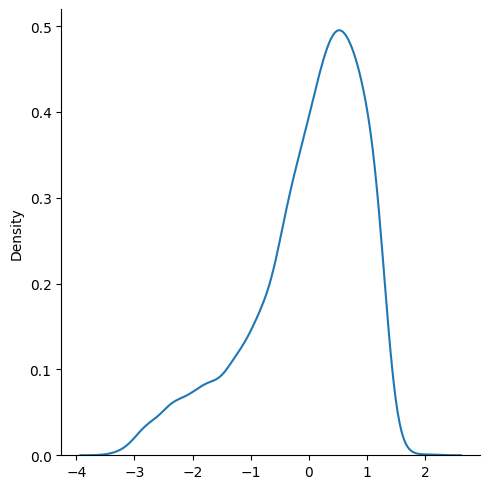

In [28]:
lasso_pred = lassocv.predict(x_test)
import seaborn as sns
sns.displot(lasso_pred-y_test,kind = 'kde')